In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
df = pd.read_csv(r'C:\CODE\python projects\sir\Medicine-Sales-Analysis-Dashboard-with-Future-Business-Predictions\csv\Mfg_Sales.csv')

In [20]:
print(df.head())

        AcYr   MMYYYY  Zone BranchName  MKTType                    BrandName  \
0  2020-2021  2020-04  EAST    CUTTACK  PILLAR             CARACSOL EYE DROP   
1  2020-2021  2020-04  EAST    CUTTACK  PILLAR     ENTEROMYCETIN CAPLETS-500   
2  2020-2021  2020-04  EAST    CUTTACK  PILLAR        ENTEROMYCETIN CAPS-250   
3  2020-2021  2020-04  EAST    CUTTACK  PILLAR   Enteromycetin OTIC SOLUTION   
4  2020-2021  2020-04  EAST    CUTTACK  PILLAR      ENTEROMYCETIN SUSPENSION   

   SalesQty   SalesAmt  CNQty    CNAmt  ActQty     ActAmt  Unnamed: 12  \
0     725.0   16776.50    1.0    21.21     724   16755.29          NaN   
1    4575.0  201426.25   50.0  2250.00    4525  199176.25          NaN   
2     187.0    7190.15   45.0  1735.65     142    5454.50          NaN   
3    2900.0   55941.00    NaN      NaN    2900   55941.00          NaN   
4    1260.0   61072.20    NaN      NaN    1260   61072.20          NaN   

  Unnamed: 13  
0         NaN  
1         NaN  
2           `  
3         

In [21]:
# Drop Unnamed columns
df = df.drop(columns=['Unnamed: 12', 'Unnamed: 13'], errors='ignore')
print(df.columns)  # Verify columns were dropped

Index(['AcYr', 'MMYYYY', 'Zone', 'BranchName', 'MKTType', 'BrandName',
       'SalesQty', 'SalesAmt', 'CNQty', 'CNAmt', 'ActQty', 'ActAmt'],
      dtype='object')


In [22]:
print(df.isna().any())

AcYr          False
MMYYYY        False
Zone           True
BranchName    False
MKTType        True
BrandName      True
SalesQty       True
SalesAmt       True
CNQty          True
CNAmt          True
ActQty        False
ActAmt        False
dtype: bool


In [23]:
# Find missing values in the current all_data
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]

print("Features with missing values:")
print(missing_data)

Features with missing values:
CNQty        15477
CNAmt        14942
SalesQty      4511
SalesAmt      4511
MKTType        126
BrandName      107
Zone            12
dtype: int64


In [24]:
df.isna().sum().sort_values(ascending=False)

CNQty         15477
CNAmt         14942
SalesQty       4511
SalesAmt       4511
MKTType         126
BrandName       107
Zone             12
AcYr              0
BranchName        0
MMYYYY            0
ActQty            0
ActAmt            0
dtype: int64

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54321 entries, 0 to 54320
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AcYr        54321 non-null  object 
 1   MMYYYY      54321 non-null  object 
 2   Zone        54309 non-null  object 
 3   BranchName  54321 non-null  object 
 4   MKTType     54195 non-null  object 
 5   BrandName   54214 non-null  object 
 6   SalesQty    49810 non-null  float64
 7   SalesAmt    49810 non-null  float64
 8   CNQty       38844 non-null  float64
 9   CNAmt       39379 non-null  float64
 10  ActQty      54321 non-null  int64  
 11  ActAmt      54321 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 5.0+ MB
None


In [26]:
# Impute numerical features with 0
numerical_cols_to_impute_zero = df.select_dtypes(include=['float64', 'object']).columns.tolist()
for col in numerical_cols_to_impute_zero:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        elif df[col].dtype == 'float64':
            df[col]= df[col].fillna(df[col].median())

In [27]:

df.isna().sum().sort_values(ascending=False)

AcYr          0
MMYYYY        0
Zone          0
BranchName    0
MKTType       0
BrandName     0
SalesQty      0
SalesAmt      0
CNQty         0
CNAmt         0
ActQty        0
ActAmt        0
dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54321 entries, 0 to 54320
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AcYr        54321 non-null  object 
 1   MMYYYY      54321 non-null  object 
 2   Zone        54321 non-null  object 
 3   BranchName  54321 non-null  object 
 4   MKTType     54321 non-null  object 
 5   BrandName   54321 non-null  object 
 6   SalesQty    54321 non-null  float64
 7   SalesAmt    54321 non-null  float64
 8   CNQty       54321 non-null  float64
 9   CNAmt       54321 non-null  float64
 10  ActQty      54321 non-null  int64  
 11  ActAmt      54321 non-null  float64
 12  Year        54321 non-null  int64  
dtypes: float64(5), int64(2), object(6)
memory usage: 5.4+ MB


In [35]:
print(df['MMYYYY'])
print(df['AcYr'])

0        2020-04
1        2020-04
2        2020-04
3        2020-04
4        2020-04
          ...   
54316    2025-10
54317    2025-10
54318    2025-10
54319    2025-10
54320    2025-10
Name: MMYYYY, Length: 54321, dtype: object
0        2020-2021
1        2020-2021
2        2020-2021
3        2020-2021
4        2020-2021
           ...    
54316    2025-2026
54317    2025-2026
54318    2025-2026
54319    2025-2026
54320    2025-2026
Name: AcYr, Length: 54321, dtype: object


In [36]:
print(df['MMYYYY'])

0        2020-04
1        2020-04
2        2020-04
3        2020-04
4        2020-04
          ...   
54316    2025-10
54317    2025-10
54318    2025-10
54319    2025-10
54320    2025-10
Name: MMYYYY, Length: 54321, dtype: object


In [ ]:
df.drop(columns=['AcYr','Year','Zone','BranchName','MKTType','BrandName','SalesQty','SalesAmt','CNQty','CNAmt','ActQty'], inplace=True, errors='ignore')

In [46]:
print(df)

                 AcYr     ActAmt
MMYYYY                          
2020-04-01  2020-2021   16755.29
2020-04-01  2020-2021  199176.25
2020-04-01  2020-2021    5454.50
2020-04-01  2020-2021   55941.00
2020-04-01  2020-2021   61072.20
...               ...        ...
2025-10-01  2025-2026   22909.60
2025-10-01  2025-2026   27857.60
2025-10-01  2025-2026     848.70
2025-10-01  2025-2026   10957.50
2025-10-01  2025-2026    1671.50

[54321 rows x 2 columns]


In [52]:
yearly_sales = df.groupby('AcYr')['ActAmt'].sum().sort_index()

print(yearly_sales)

AcYr
2020-2021    1.103230e+09
2021-2022    1.276251e+09
2022-2023    1.214682e+09
2023-2024    1.282394e+09
2024-2025    1.254944e+09
2025-2026    5.398471e+08
Name: ActAmt, dtype: float64


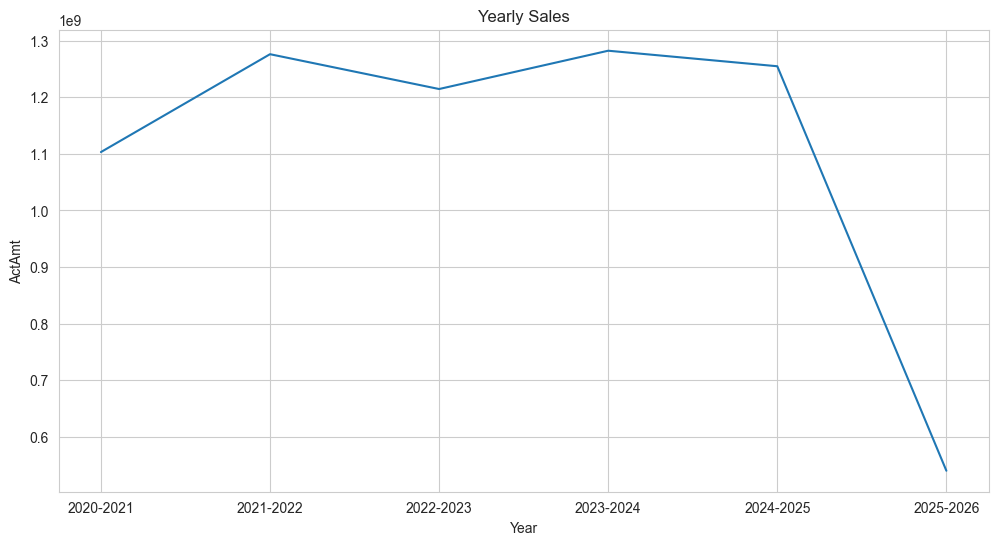

In [53]:
plt.figure()
plt.plot(yearly_sales)
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("ActAmt")
plt.show()


In [54]:
train_size = int(len(yearly_sales) * 0.8)

train = yearly_sales[:train_size]

test = yearly_sales[train_size:]


In [74]:
df = df[['AcYr', 'ActAmt']]

# Convert ActAmt to numeric
df['ActAmt'] = pd.to_numeric(df['ActAmt'], errors='coerce')

df = df.fillna(0)

# Extract start year from AcYr
df['Year'] = df['AcYr'].str[:4].astype(int)

# Group by Year (important)
yearly_sales = df.groupby('Year')['ActAmt'].sum()

# Sort
yearly_sales = yearly_sales.sort_index()

print("Training Data:")
print(yearly_sales)

# Train ARIMA model
model = ARIMA(yearly_sales, order=(1,1,1))

model_fit = model.fit()



Training Data:
Year
2020    1.103230e+09
2021    1.276251e+09
2022    1.214682e+09
2023    1.282394e+09
2024    1.254944e+09
2025    5.398471e+08
Name: ActAmt, dtype: float64


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\sit

In [70]:
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)


MAE: 370787953.29841703


In [82]:

# USER INPUT SESSION
user_session = input("\nEnter session (example: 2025-2026): ")

# Extract year from session
input_year = int(user_session[:4])

# Last available year in data
last_year = yearly_sales.index.max()

# Calculate steps ahead
steps = input_year - last_year

if steps <= 0:
    print("Session already exists or invalid")

else:
    forecast = model_fit.forecast(steps=steps)

    predicted_value = forecast.iloc[-1]

    print(f"\nPredicted ActAmt for session {user_session} = {predicted_value:.2f}")


ValueError: Prediction must have `end` after `start`.

In [79]:
last_year = int(yearly_sales.index.max())

user_year = int(user_year) if isinstance(user_year, str) else user_year

steps = user_year - last_year

if steps <= 0:
    print("Enter a year in the future")
else:
    forecast = model_fit.forecast(steps=steps)

    predicted_value = forecast.iloc[-1]

    print(f"\nPredicted ActAmt for year {user_year} = {predicted_value:.2f}")


Predicted ActAmt for year 2028 = 539846442.71


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


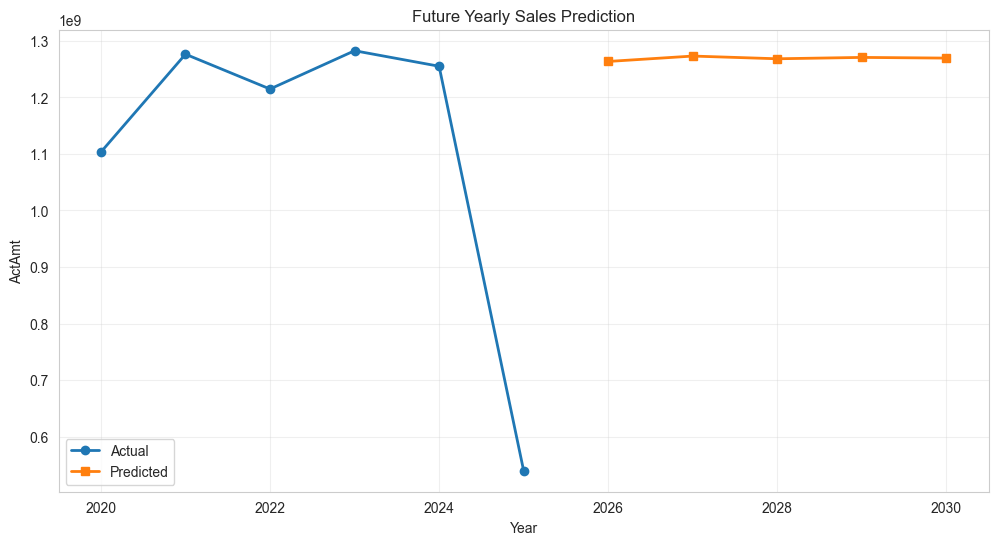

In [83]:
plt.figure(figsize=(12, 6))

# Extract numeric years from index
actual_years = [int(str(year).split('-')[0]) if '-' in str(year) else int(year) for year in yearly_sales.index]

# Create future years
last_year = int(yearly_sales.index.max()) if isinstance(yearly_sales.index.max(), str) else yearly_sales.index.max()
future_years_list = list(range(last_year + 1, last_year + len(future_predictions) + 1))

plt.plot(actual_years, yearly_sales.values, label="Actual", marker='o', linewidth=2)
plt.plot(future_years_list, future_predictions.values, label="Predicted", marker='s', linewidth=2)

plt.legend()
plt.title("Future Yearly Sales Prediction")
plt.xlabel("Year")
plt.ylabel("ActAmt")
plt.grid(True, alpha=0.3)
plt.show()